In [1]:
import sys
from pathlib import Path

project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.systems.newton_system import newton_system
from src.systems.broyden import broyden

In [3]:
def F(v):
    x, y = v

    return np.array([
        x**2 + y**2 - 5,
        np.exp(x) + y - 1
    ])


def J(v):
    x, y = v

    return np.array([
        [2*x, 2*y],
        [np.exp(x), 1]
    ])

In [4]:
x0 = np.array([1.0, -1.0])

system_methods = {
    "Newton System": newton_system(F, J, x0),
    "Broyden": broyden(F, x0, B0=J(x0)),
}

system_summary = []

for name, result in system_methods.items():
    system_summary.append({
        "Method": name,
        "Root": result["root"],
        "Converged": result["converged"],
        "Iterations": result["iterations"],
        "Final Error": result["final_error"],
        "Final Residual": result["final_residual"],
        "Message": result["message"],
    })

df_system_summary = pd.DataFrame(system_summary)
df_system_summary

,Method,Root,Converged,Iterations,Final Error,Final Residual,Message
0,Newton System,"[1.0837904910011344, -1.9558625134746868]",True,5,8.184299e-09,2.220446e-16,converged by residual tolerance
1,Broyden,"[1.0837904909251623, -1.9558625136165975]",True,7,6.842545e-07,5.354870e-10,converged by residual tolerance


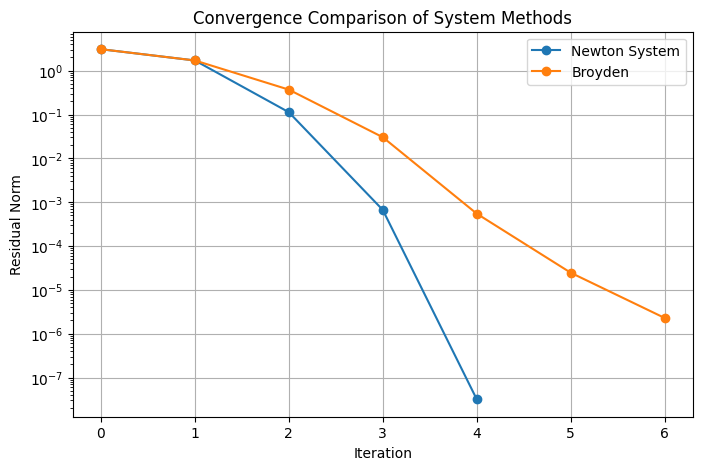

In [5]:
plt.figure(figsize=(8, 5))

for name, result in system_methods.items():

    residuals = []

    for step in result["history"]:

        if "norm_f" in step:
            residuals.append(abs(step["norm_f"]))

    plt.semilogy(
        range(len(residuals)),
        residuals,
        marker="o",
        label=name
    )

plt.xlabel("Iteration")
plt.ylabel("Residual Norm")
plt.title("Convergence Comparison of System Methods")

plt.legend()
plt.grid(True)

plt.savefig(
    "../latex/figures/system_methods_convergence.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()